# Carregamento dos dados

In [1]:
import os
import copy
import json
import time
import random
from pathlib import Path
#import yaml
import itertools
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


import sys
sys.path.append("C:/Users/loren/GNNGCN-proj/src")

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-12-31"

In [2]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32

In [3]:
catalog_dir = Path("C:/Users/loren/GNNGCN-proj") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


In [4]:
base = "C:/Users/loren/GNNGCN-proj"
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"                                    # Início do período
end_date   = "2025-12-31"                                    # Fim do período
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_05-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "era5_vv_06-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações
 
 

In [5]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

In [6]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

In [7]:
# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

In [8]:
k = 61

In [9]:
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# Cria uma matriz N x N preenchida com zeros
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

# Agregação por média

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
A_norm = torch.tensor(A / deg, dtype=torch.float32) 

In [10]:
target_date = "2025-02-08"

In [11]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

n_idx = 32 # ID da estação (32 - Porto Alegre, Jardim Botânico)
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
epochs = 200 # Épocas
hidden = 2 # Número de neurônios na camada oculta
lr = 1e-3 # Taxa de aprendizado "eta".

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.10
p_test  = 0.20  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

Total de nós: 62
  Treino: 43  Val: 6  Teste: 13


#  Montagem do grafo

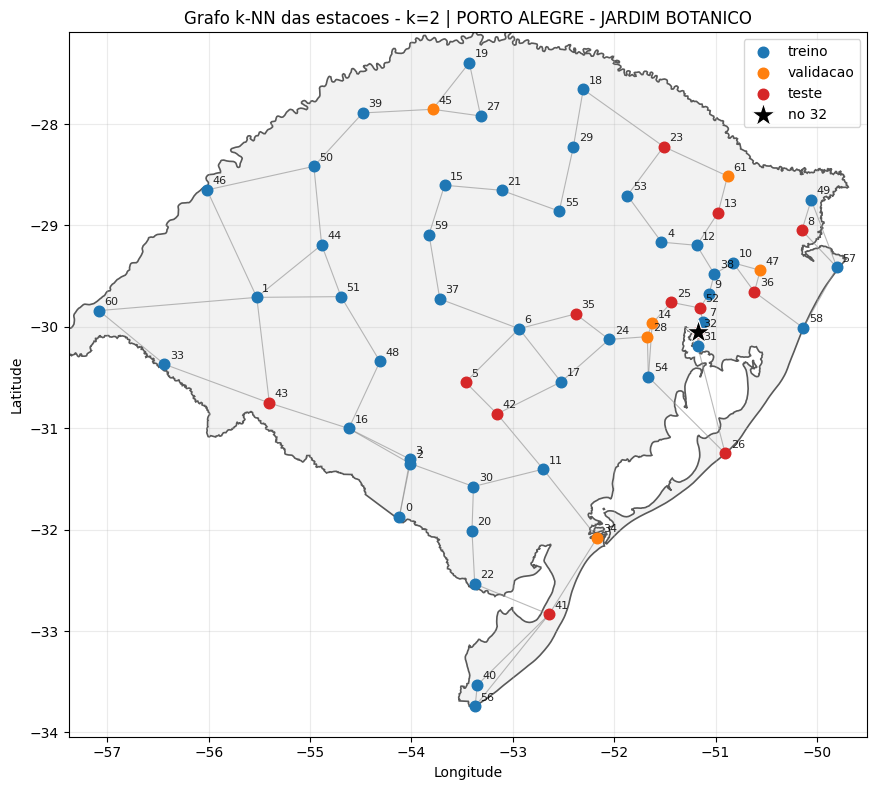

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=2:
  no   7 -> CACHOEIRINHA
  no  31 -> PORTO ALEGRE - BELEM NOVO


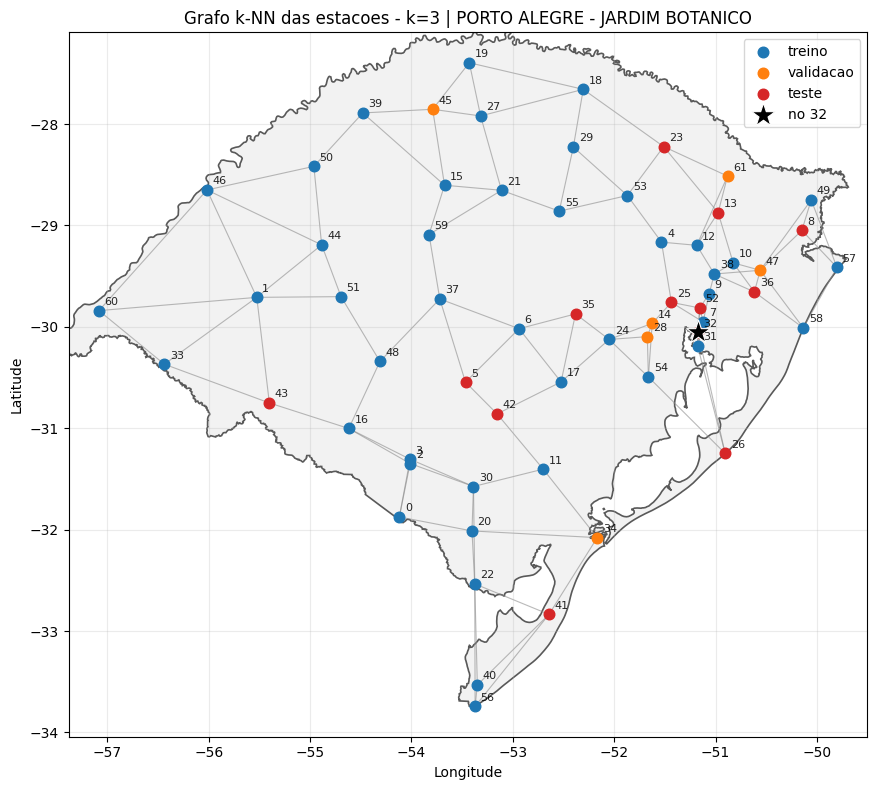

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=3:
  no   7 -> CACHOEIRINHA
  no  26 -> MOSTARDAS
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  52 -> SAPUCAIA DO SUL


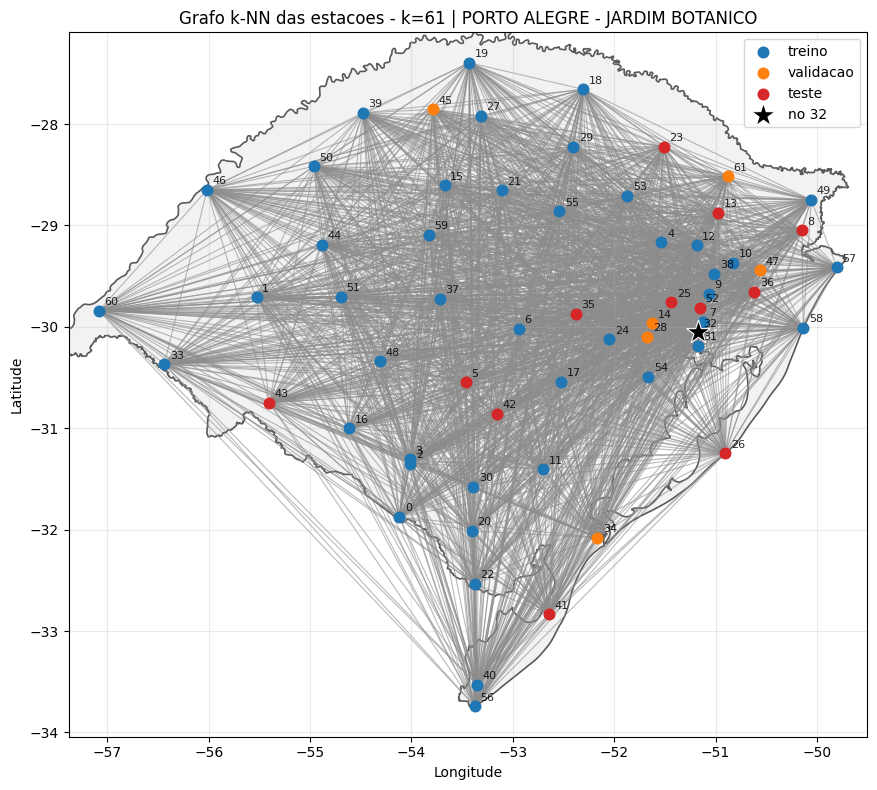

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=61:
  no   0 -> ACEGUA
  no   1 -> ALEGRETE
  no   2 -> BAGE
  no   3 -> BAGE - CENTRO
  no   4 -> BENTO GONCALVES
  no   5 -> CACAPAVA DO SUL
  no   6 -> CACHOEIRA DO SUL
  no   7 -> CACHOEIRINHA
  no   8 -> CAMBARA DO SUL
  no   9 -> CAMPO BOM
  no  10 -> CANELA
  no  11 -> CANGUCU
  no  12 -> CAXIAS DO SUL - AEROPORTO
  no  13 -> CAXIAS DO SUL - CRIUVA
  no  14 -> CHARQUEADAS
  no  15 -> CRUZ ALTA
  no  16 -> DOM PEDRITO
  no  17 -> ENCRUZILHADA DO SUL
  no  18 -> ERECHIM
  no  19 -> FREDERICO WESTPHALEN
  no  20 -> HERVAL
  no  21 -> IBIRUBA
  no  22 -> JAGUARAO
  no  23 -> LAGOA VERMELHA
  no  24 -> MINAS DO LEAO
  no  25 -> MONTENEGRO
  no  26 -> MOSTARDAS
  no  27 -> PALMEIRA DAS MISSOES
  no  28 -> PARQUE ELDORADO
  no  29 -> PASSO FUNDO
  no  30 -> PINHEIRO MACHADO
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  33 -> QUARAI
  no  34 -> RIO GRANDE
  no  35 -> RIO PARDO
  no  36 -> ROLANTE
  no  37 -> SANTA MARIA
  n

In [12]:
import json
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

n_idx = 32  # Índice do nó para destacar (estação no índice 32)

def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        }
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    # Se vier compactado em gzip, descompacta antes de decodificar
    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=0
            )


def build_adjacency(coords, k=2, include_self=False):
    coords = np.asarray(coords, dtype=float)
    N = coords.shape[0]

    if k >= N:
        raise ValueError(f"k={k} precisa ser menor que o numero de nos N={N}.")

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A_bin = np.zeros((N, N), dtype=bool)

    for i in range(N):
        A_bin[i, idx[i]] = True

    A_bin = A_bin | A_bin.T

    if include_self:
        np.fill_diagonal(A_bin, True)
    else:
        np.fill_diagonal(A_bin, False)

    return A_bin


def as_numpy_mask(mask):
    if hasattr(mask, "detach"):
        return mask.detach().cpu().numpy().astype(bool)
    return np.asarray(mask, dtype=bool)


def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
                   mask_train=None, mask_val=None, mask_test=None,
                   figsize=(11, 8), label_nodes=True,
                   mapa_rs=None):

    coords = np.asarray(coords, dtype=float)
    A_bin = build_adjacency(coords, k=k, include_self=False)
    N = coords.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson(ax, mapa_rs)

    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="0.55",
                    linewidth=0.8,
                    alpha=0.6,
                    zorder=1,
                )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = as_numpy_mask(mask_train)
        val = as_numpy_mask(mask_val)
        test = as_numpy_mask(mask_test)

        ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
        ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
        ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
    else:
        ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

    ax.scatter(
        coords[n_idx, 1],
        coords[n_idx, 0],
        s=320,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        label=f"no {n_idx}",
        zorder=5,
    )

    if label_nodes:
        for i in range(N):
            ax.annotate(
                str(i),
                (coords[i, 1], coords[i, 0]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
                zorder=6,
            )

    vizinhos = np.where(A_bin[n_idx])[0]
    nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

    lon = coords[:, 1]
    lat = coords[:, 0]

    ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
    ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Vizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
    for j in vizinhos:
        nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
        print(f"  no {j:3d} -> {nome_vizinho}")

    return A_bin


mapa_rs = carregar_mapa_rs_ibge()

A_grafo2 = plot_knn_graph(coords, k=2, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo3 = plot_knn_graph(coords, k=3, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo61 = plot_knn_graph(coords, k=61, n_idx=n_idx, nomes=nomes,
                           mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                           figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)